In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
features = [
    "dividend_yield",
    "dividend_growth",
    "dividend_consistency",
    "return_volatility"
]

print("Features:")
for feature in features:
    print("-", feature)

Features:
- dividend_yield
- dividend_growth
- dividend_consistency
- return_volatility


In [3]:
linear_importance = pd.DataFrame({
    "Feature": [
        "dividend_yield",
        "dividend_growth",
        "dividend_consistency",
        "return_volatility"
    ],
    "Coefficient": [
        -5.239004,
        -0.727658,
        0.0,
        0.450775
    ]
})

linear_importance["Absolute_Importance"] = (
    linear_importance["Coefficient"].abs()
)

print(linear_importance)

                Feature  Coefficient  Absolute_Importance
0        dividend_yield    -5.239004             5.239004
1       dividend_growth    -0.727658             0.727658
2  dividend_consistency     0.000000             0.000000
3     return_volatility     0.450775             0.450775


In [4]:
linear_importance["Normalized_Importance"] = (
    linear_importance["Absolute_Importance"] /
    linear_importance["Absolute_Importance"].sum()
)

print(linear_importance.round(4))

                Feature  Coefficient  Absolute_Importance  \
0        dividend_yield      -5.2390               5.2390   
1       dividend_growth      -0.7277               0.7277   
2  dividend_consistency       0.0000               0.0000   
3     return_volatility       0.4508               0.4508   

   Normalized_Importance  
0                 0.8164  
1                 0.1134  
2                 0.0000  
3                 0.0702  


In [5]:
xgb_importance = pd.DataFrame({
    "Feature": [
        "dividend_yield",
        "dividend_growth",
        "dividend_consistency",
        "return_volatility"
    ],
    "XGBoost_Importance": [
        0.369330,
        0.368466,
        0.000000,
        0.262203
    ]
})

print(xgb_importance)

                Feature  XGBoost_Importance
0        dividend_yield            0.369330
1       dividend_growth            0.368466
2  dividend_consistency            0.000000
3     return_volatility            0.262203


In [6]:
print(
    "Total XGBoost importance:",
    xgb_importance["XGBoost_Importance"].sum()
)

Total XGBoost importance: 0.9999990000000001


In [7]:
importance = linear_importance[
    ["Feature", "Coefficient", "Normalized_Importance"]
].merge(
    xgb_importance,
    on="Feature"
)

print(importance.round(4))

                Feature  Coefficient  Normalized_Importance  \
0        dividend_yield      -5.2390                 0.8164   
1       dividend_growth      -0.7277                 0.1134   
2  dividend_consistency       0.0000                 0.0000   
3     return_volatility       0.4508                 0.0702   

   XGBoost_Importance  
0              0.3693  
1              0.3685  
2              0.0000  
3              0.2622  


In [8]:
importance["Overall_Importance"] = (
    importance["Normalized_Importance"] +
    importance["XGBoost_Importance"]
) / 2

importance = importance.sort_values(
    "Overall_Importance",
    ascending=False
).reset_index(drop=True)

print(importance.round(4))

                Feature  Coefficient  Normalized_Importance  \
0        dividend_yield      -5.2390                 0.8164   
1       dividend_growth      -0.7277                 0.1134   
2     return_volatility       0.4508                 0.0702   
3  dividend_consistency       0.0000                 0.0000   

   XGBoost_Importance  Overall_Importance  
0              0.3693              0.5929  
1              0.3685              0.2409  
2              0.2622              0.1662  
3              0.0000              0.0000  


In [9]:
print("\nFeature Importance Ranking")
print("--------------------------")

for i, row in importance.iterrows():
    print(
        f"{i + 1}. {row['Feature']} : "
        f"{row['Overall_Importance']:.4f}"
    )


Feature Importance Ranking
--------------------------
1. dividend_yield : 0.5929
2. dividend_growth : 0.2409
3. return_volatility : 0.1662
4. dividend_consistency : 0.0000


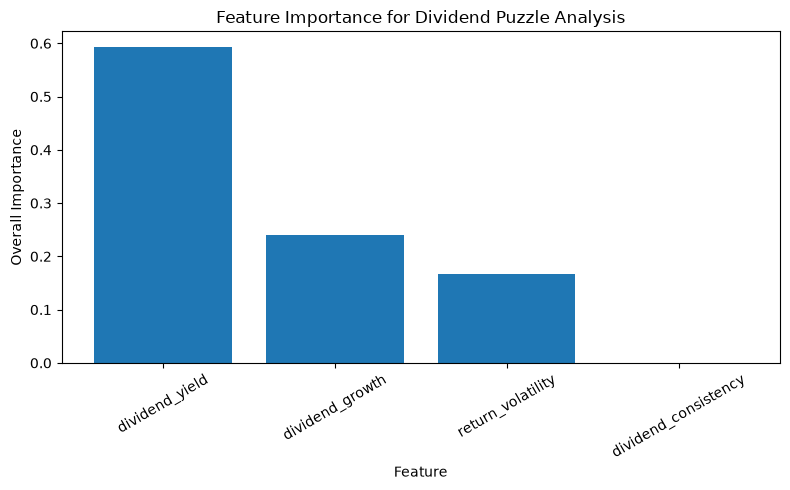

In [10]:
plt.figure(figsize=(8, 5))

plt.bar(
    importance["Feature"],
    importance["Overall_Importance"]
)

plt.xlabel("Feature")
plt.ylabel("Overall Importance")
plt.title("Feature Importance for Dividend Puzzle Analysis")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [11]:
best_feature = importance.loc[
    importance["Overall_Importance"].idxmax(),
    "Feature"
]

print("Most important feature:", best_feature)

Most important feature: dividend_yield


In [12]:
output_file = "../datasets/processed/day26_feature_importance.csv"

importance.to_csv(
    output_file,
    index=False
)

print("Day 26 feature importance saved successfully!")
print("File:", output_file)

Day 26 feature importance saved successfully!
File: ../datasets/processed/day26_feature_importance.csv


In [13]:
print(
    "File exists:",
    os.path.exists(output_file)
)

print(
    "File size:",
    os.path.getsize(output_file),
    "bytes"
)

File exists: True
File size: 342 bytes


In [14]:
print(importance.round(4))

                Feature  Coefficient  Normalized_Importance  \
0        dividend_yield      -5.2390                 0.8164   
1       dividend_growth      -0.7277                 0.1134   
2     return_volatility       0.4508                 0.0702   
3  dividend_consistency       0.0000                 0.0000   

   XGBoost_Importance  Overall_Importance  
0              0.3693              0.5929  
1              0.3685              0.2409  
2              0.2622              0.1662  
3              0.0000              0.0000  


In [15]:
print(
    "Feature importance file exists:",
    os.path.exists(
        "../datasets/processed/day26_feature_importance.csv"
    )
)

Feature importance file exists: True
